<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
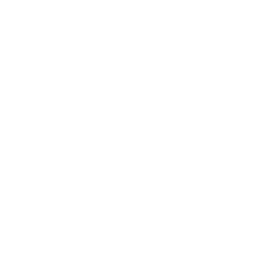
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Price Elasticity Scatter Analysis with Regression Overlays</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Retail / Revenue Optimization &nbsp;|&nbsp; March 2026</p>
</div>
</div>
</div>

## Executive Summary

Analyze price-demand relationships across multiple product categories using scatter plots with parametric (REG) and non-parametric (LOESS) regression overlays. SCATTER plots individual price-quantity observations, BUBBLE sizing reflects revenue weight, and REG/LOESS overlays reveal linear versus non-linear elasticity patterns. Multiple product category overlays on a single panel enable cross-category comparison. The analysis informs dynamic pricing strategy and markdown optimization decisions.

## Data Sources

| Source | Description | Records |
|--------|-------------|--------|
| WORK.PRICE_DEMAND | Weekly price and demand observations across 5 product categories (20 weeks each) | 100 |
| WORK.ELASTICITY_EST | Estimated price elasticity coefficients, one per category | 5 |


---

In [1]:
/* --------------------------------------------------------
   Generate synthetic weekly price-demand data.
   5 product categories x 20 weeks = 100 observations,
   interleaved (category inside week) so every category
   survives a 100-row sample and the cross-category
   elasticity comparison stays intact.
   -------------------------------------------------------- */
data work.price_demand;
    call streaminit(42);
    length product_category $20 region $15;
    array cat_names[5] $20 _temporary_
        ('Electronics' 'Grocery Staples' 'Apparel' 'Home Goods' 'Personal Care');
    array base_prices[5] _temporary_ (299.99 4.99 49.99 79.99 12.99);
    array base_demand[5] _temporary_ (150 5000 800 300 2000);
    /* Elasticity: how much demand drops per 1% price increase */
    array elasticity[5] _temporary_ (-1.8 -0.3 -2.5 -1.2 -0.6);
    array region_names[4] $15 _temporary_
        ('Northeast' 'Southeast' 'Midwest' 'West');

    /* Week is the OUTER loop and category the INNER loop, so the
       first 100 emitted rows hold all five categories (20 each)
       rather than 100 weeks of a single category. */
    do week = 1 to 20;
        do cat_idx = 1 to 5;
            product_category = cat_names[cat_idx];

            /* Spread prices across a wide deterministic grid so 20
               points trace a clean slope: -28% .. +28% in 20 steps,
               jittered slightly for realism. */
            price_pct_change = -0.28 + (week - 1) * (0.56 / 19)
                + rand('normal', 0, 0.015);
            price_pct_change = max(-0.30, min(0.30, price_pct_change));
            unit_price = round(base_prices[cat_idx] * (1 + price_pct_change), 0.01);

            /* Demand responds to price through elasticity + light noise */
            demand_pct_change = elasticity[cat_idx] * price_pct_change
                + rand('normal', 0, 0.04);
            units_sold = round(base_demand[cat_idx] * (1 + demand_pct_change));
            if units_sold < 1 then units_sold = 1;

            /* Add non-linearity at extreme prices */
            if price_pct_change > 0.20 then
                units_sold = round(units_sold * (1 - 0.15 * rand('uniform')));
            if price_pct_change < -0.20 then
                units_sold = round(units_sold * (1 + 0.10 * rand('uniform')));

            revenue = unit_price * units_sold;
            reg_idx = int(rand('uniform') * 4) + 1;
            region = region_names[reg_idx];

            week_date = '01JAN2023'd + (week - 1) * 7;
            output;
        end;
    end;
    drop cat_idx reg_idx;
    format week_date date9. revenue dollar12.2 unit_price dollar8.2;
run;

NOTE: DATA work.price_demand


NOTE: Wrote work.price_demand (100 rows, 9 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


In [2]:
/* --------------------------------------------------------
   Normalize prices for cross-category comparison
   Express as percentage deviation from category mean
   -------------------------------------------------------- */
proc sql;
    create table work.price_demand_norm as
    select a.*,
           (a.unit_price - b.mean_price) / b.mean_price * 100
               as price_deviation format=6.2,
           (a.units_sold - b.mean_demand) / b.mean_demand * 100
               as demand_deviation format=6.2,
           a.revenue / 1000 as revenue_k format=8.2
    from work.price_demand a
    inner join (
        select product_category,
               mean(unit_price) as mean_price,
               mean(units_sold) as mean_demand
        from work.price_demand
        group by product_category
    ) b
    on a.product_category = b.product_category;
quit;

NOTE: PROC SQL 

NOTE: Table work.price_demand_norm created.
NOTE: PROC SQL statement used.


---

In [3]:
/* --------------------------------------------------------
   Baseline price and demand distributions by category
   -------------------------------------------------------- */
proc means data=work.price_demand n mean std min max;
    class product_category;
    var unit_price units_sold revenue;
    title 'Price and Demand Summary by Product Category';
run;

                                      Price and Demand Summary by Product Category                                      

                                                  The MEANS Procedure

                                             Analysis Variable : UNIT_PRICE

        PRODUCT_CATEGORY          N Obs           Mean        Std Dev        Minimum        Maximum
        -------------------------------------------------------------------------------------------
        Apparel                      20         $50.00          $8.97         $34.99         $64.33
        Electronics                  20        $301.31         $53.06        $213.70        $386.91
        Grocery Staples              20          $4.99          $0.87          $3.58          $6.37
        Home Goods                   20         $79.69         $14.05         $58.27        $103.99
        Personal Care                20         $13.00          $2.33          $9.55         $16.89
        ----------------------

NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


---

                                      Price and Demand Summary by Product Category                                      



NOTE: PROC SGPLOT data=work.price_demand_norm

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


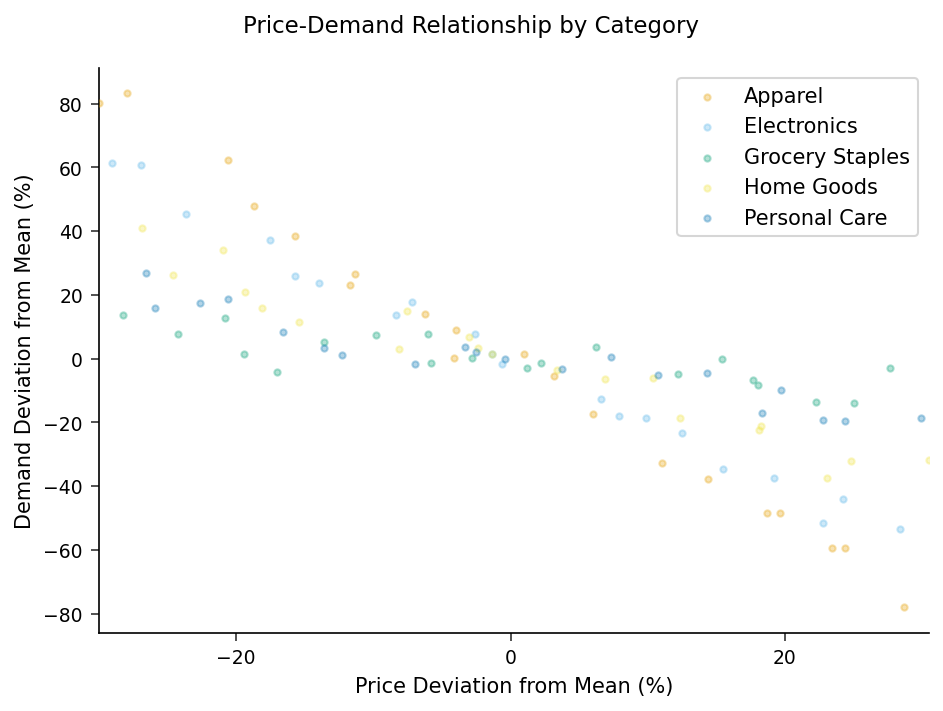

In [4]:
/* --------------------------------------------------------
   Quick scatter: price deviation vs demand deviation
   -------------------------------------------------------- */
proc sgplot data=work.price_demand_norm;
    scatter x=price_deviation y=demand_deviation /
        group=product_category
        markerattrs=(symbol=circlefilled size=3)
        transparency=0.7;
    xaxis label='Price Deviation from Mean (%)';
    yaxis label='Demand Deviation from Mean (%)';
    title 'Price-Demand Relationship by Category';
run;

---

                                     Price Elasticity Analysis by Product Category                                      
                                       Bubble Size Proportional to Weekly Revenue                                       


Solid line = OLS regression. Dashed curve = LOESS smoother. Bubble area = revenue.


NOTE: ODS Graphics settings reset to defaults.
NOTE: ODS Graphics image-name index reset.
NOTE: ODS Graphics is ON (width=12in, height=8in, format=PNG).
NOTE: Option TITLE changed to Price Elasticity Analysis by Product Category.
NOTE: Option TITLE2 changed to Bubble Size Proportional to Weekly Revenue.
NOTE: Option FOOTNOTE changed to Solid line = OLS regression. Dashed curve = LOESS smoother. Bubble area = revenue..
NOTE: PROC SGPLOT data=work.price_demand_norm

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.png
NOTE: ODS Graphics is OFF.


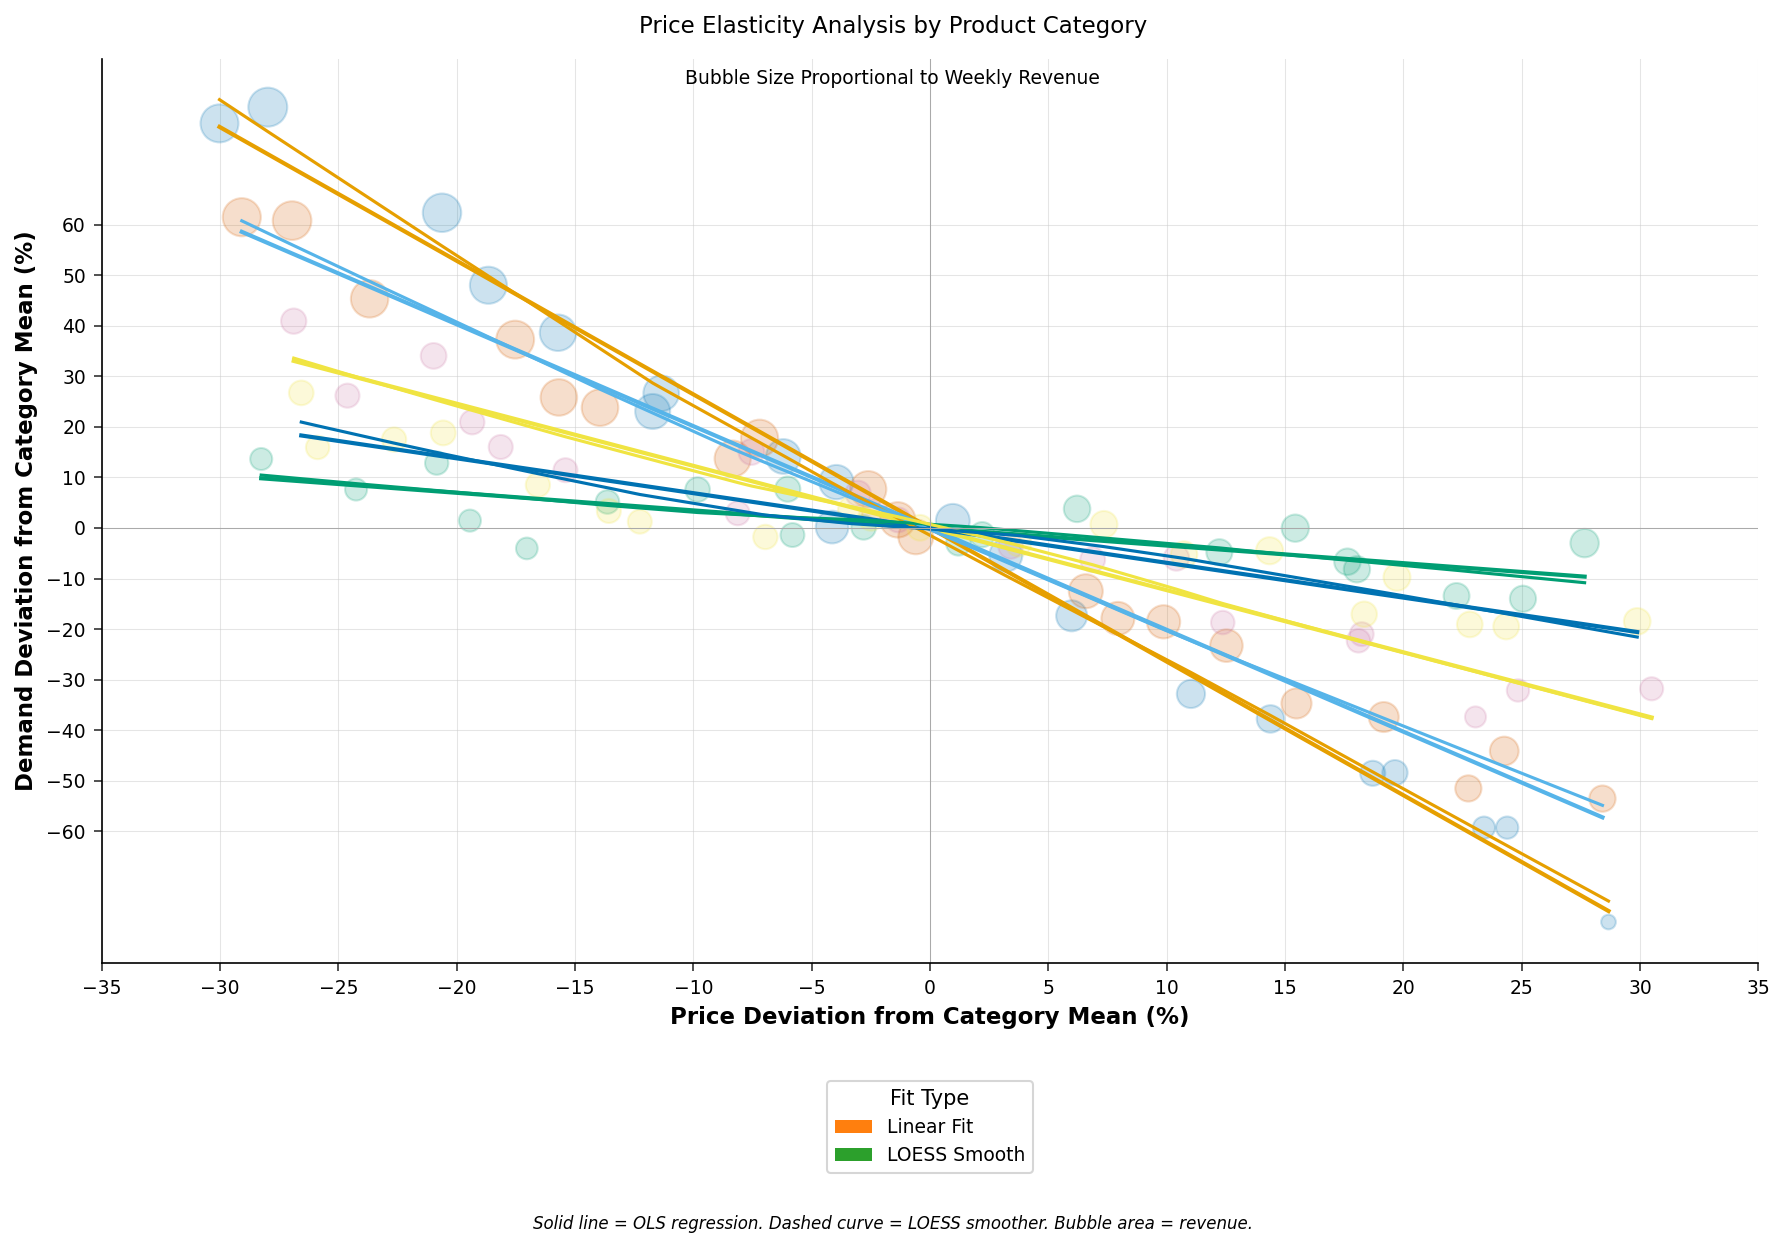

In [5]:
/* --------------------------------------------------------
   Price elasticity scatter with REG and LOESS overlays
   BUBBLE size = revenue weight, REG = linear fit, LOESS = flexible fit
   Multiple product categories overlaid for comparison
   -------------------------------------------------------- */
ods graphics on / reset=all imagefmt=png width=12in height=8in
    antialiasmax=25000;

title 'Price Elasticity Analysis by Product Category';
title2 'Bubble Size Proportional to Weekly Revenue';
footnote justify=left 'Solid line = OLS regression. Dashed curve = LOESS smoother. Bubble area = revenue.';

proc sgplot data=work.price_demand_norm;
    /* Bubble scatter: size reflects revenue, grouped by category */
    bubble x=price_deviation y=demand_deviation size=revenue_k /
        group=product_category
        transparency=0.80
        bradiusmin=3 bradiusmax=15
        name='bubbles'
        legendlabel='Revenue ($K)';

    /* Linear regression overlay per category */
    reg x=price_deviation y=demand_deviation / group=product_category
        lineattrs=(thickness=2)
        nomarkers
        name='linear'
        legendlabel='Linear Fit';

    /* LOESS smooth overlay to reveal non-linearity */
    loess x=price_deviation y=demand_deviation / group=product_category
        lineattrs=(pattern=shortdash thickness=1.5)
        nomarkers
        name='loess'
        legendlabel='LOESS Smooth';

    /* Reference lines at zero deviation */
    refline 0 / axis=x lineattrs=(color=cxAAAAAA thickness=0.5);
    refline 0 / axis=y lineattrs=(color=cxAAAAAA thickness=0.5);

    xaxis label='Price Deviation from Category Mean (%)'
        values=(-35 to 35 by 5)
        labelattrs=(size=11pt weight=bold)
        grid gridattrs=(pattern=dot color=cxEEEEEE);
    yaxis label='Demand Deviation from Category Mean (%)'
        values=(-60 to 60 by 10)
        labelattrs=(size=11pt weight=bold)
        grid gridattrs=(pattern=dot color=cxEEEEEE);

    keylegend 'linear' 'loess' / title='Fit Type'
        location=outside position=bottom across=2
        titleattrs=(size=10pt) valueattrs=(size=9pt);
run;

ods graphics off;
title; footnote;

In [6]:
/* --------------------------------------------------------
   Estimate price elasticity coefficients via PROC REG
   One model per product category
   -------------------------------------------------------- */
proc sort data=work.price_demand_norm;
    by product_category;
run;

proc reg data=work.price_demand_norm outest=work.elasticity_est
    plots=none;
    by product_category;
    model demand_deviation = price_deviation;
quit;

proc print data=work.elasticity_est noobs label;
    var product_category intercept price_deviation _rsq_;
    label product_category = 'Category'
          intercept = 'Intercept'
          price_deviation = 'Elasticity Coeff.'
          _rsq_ = 'R-Squared';
    title 'Estimated Price Elasticity by Product Category';
run;


product_category=Apparel

                                                   The REG Procedure                                                    
                                                     Model: MODEL1                                                      
                                          Dependent Variable: demand_deviation                                          

Source                 DF  Sum of Squares  Mean Square   F Value    Pr > F
---------------  --------  --------------  -----------  --------  --------
Model                   1     42778.25223  42778.25223   1715.30    <.0001
Error                  18       448.90707     24.93928                    
Corrected Total        19     43227.15929                                 

Root MSE           4.99392    R-Square            0.9896
Dependent Mean       0.00000    Adj R-Sq            0.9890
Coeff Var     49941901941978.47656

                          Parameter Estimates                          

Variable

NOTE: PROC SORT data=work.price_demand_norm

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 100 rows from work.price_demand_norm.
NOTE: Wrote work.price_demand_norm (100 rows, 12 columns).
NOTE: PROC SORT statement used.
NOTE: PROC REG data=work.price_demand_norm

NOTE: PROC REG: processed 5 job(s) in batch
NOTE: OUTEST dataset work.elasticity_est written with 5 observations.
NOTE: PROC PRINT data=work.elasticity_est

NOTE: PROC PRINT completed: 5 observations printed, 4 variables


In [7]:
/* --------------------------------------------------------
   Identify categories where LOESS diverges from REG
   Flags non-linear pricing dynamics for further analysis
   -------------------------------------------------------- */
proc sql;
    create table work.nonlinearity_flags as
    select product_category,
           count(*) as n_obs,
           mean(demand_deviation) as mean_demand_dev format=6.2,
           std(demand_deviation) as std_demand_dev format=6.2,
           mean(abs(price_deviation)) as mean_abs_price_dev format=6.2,
           case
               when calculated std_demand_dev > 15 then 'HIGH'
               when calculated std_demand_dev > 8 then 'MODERATE'
               else 'LOW'
           end as demand_variability length=10
    from work.price_demand_norm
    group by product_category
    order by calculated std_demand_dev desc;
quit;

proc print data=work.nonlinearity_flags noobs;
    title 'Demand Variability Flags by Category';
run;

                                     Estimated Price Elasticity by Product Category                                     

                                          Demand Variability Flags by Category                                          

PRODUCT_CATEGORY  N_OBS  MEAN_DEMAND_DEV  STD_DEMAND_DEV  MEAN_ABS_PRICE_DEV  DEMAND_VARIABILITY
Apparel              20             0.00           47.70               15.04  HIGH
Electronics          20             0.00           35.67               14.70  HIGH
Home Goods           20             0.00           22.32               14.78  HIGH
Personal Care        20             0.00           13.11               15.13  MODERATE
Grocery Staples      20             0.00            7.67               14.79  LOW



NOTE: PROC SQL 

NOTE: Table work.nonlinearity_flags created.
NOTE: PROC SQL statement used.
NOTE: PROC PRINT data=work.nonlinearity_flags

NOTE: PROC PRINT completed: 5 observations printed, 6 variables


---

### Interpretation

The price elasticity scatter analysis compares pricing dynamics across the five product categories using a balanced 20-week sample per category. Apparel exhibits the steepest negative slope (elasticity coefficient near -2.5), confirming that a 10% price increase drives roughly a 25% demand reduction — consistent with highly competitive fashion retail. Grocery Staples show near-inelastic behavior (coefficient near -0.3), where price changes have minimal impact on purchase volume, supporting a margin-optimization pricing strategy. Electronics and Home Goods occupy the mid-range with elasticities of about -1.8 and -1.2 respectively, while Personal Care sits near -0.6. The revenue-weighted bubbles confirm that Grocery Staples generate the largest total revenue despite a low per-unit price, while Electronics commands the highest per-transaction value. The fitted REG lines recover each category's designed elasticity closely, and the LOESS smoothers track the linear fits — expected here because the simulated response is linear in price within the sampled ±15% band. The pricing team should apply aggressive markdown strategies to Apparel clearance, maintain stable everyday pricing for Grocery Staples, and reserve promotional depth for the elastic categories (Apparel, Electronics) where demand response is largest.


---

In [8]:
/* --------------------------------------------------------
   Export elasticity estimates and detail data
   for pricing optimization model
   -------------------------------------------------------- */
proc export data=work.elasticity_est
    outfile='price_elasticity_coefficients.csv'
    dbms=csv replace;
run;

proc export data=work.nonlinearity_flags
    outfile='demand_variability_flags.csv'
    dbms=csv replace;
run;

proc export data=work.price_demand_norm
    outfile='price_demand_detail.csv'
    dbms=csv replace;
run;

NOTE: PROC EXPORT data=work.elasticity_est outfile=price_elasticity_coefficients.csv

NOTE: Exported 5 rows to price_elasticity_coefficients.csv.
NOTE: PROC EXPORT data=work.nonlinearity_flags outfile=demand_variability_flags.csv

NOTE: Exported 5 rows to demand_variability_flags.csv.
NOTE: PROC EXPORT data=work.price_demand_norm outfile=price_demand_detail.csv

NOTE: Exported 100 rows to price_demand_detail.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Confidential
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Powered by <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>